In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import pingouin
import matplotlib.pyplot as plt
import seaborn as sns
from PlanningDynamics import utils, plotting, graph
from PlanningDynamics.dataClass import nwbWrapper
from sklearn.linear_model import LinearRegression

In [2]:
fnames = utils.get_filenames()

from matplotlib.colors import LinearSegmentedColormap
def interpolate_colors(color1, color2, num_colors):
    cmap = LinearSegmentedColormap.from_list('custom_cmap', [color1, color2], N=num_colors)
    colors = [cmap(i) for i in range(num_colors)]
    return colors

choice_colors = interpolate_colors(color2="#ff0000", color1="#ff75ac", num_colors=4)
plan_colors = interpolate_colors(color2="#0073ff", color1="#69d9ff", num_colors=4)

In [3]:
from matplotlib.patches import Rectangle
def choice_and_plan_value_psth(ax, data, unit):
    plan_data = data.get_plan_spikes(type="psth", min_duration=100, active_prob_threshold=0.1)
    values = utils.distance_to_value(data.choice_df.graph_distance.values)
    value_argsort = np.argsort(values)
    values = values[value_argsort]
    
    spikes = data.choice_spikes[value_argsort, :, unit]
    w = 75
    smoothed_spikes = utils.movmean(spikes, w)
    Y, X = np.where(spikes)
    for v in [1, 2, 3, 4]:
        idx = np.where(values == v)[0]
        if len(idx) == 0:
            continue
        t = np.arange(-500, 500)
        fr = smoothed_spikes[idx, :].mean(axis=0)*1000
        steps = np.arange(0, len(t), 10) + 5
        ax[2].plot(t[steps], fr[steps], label=f"Value {v}", c=choice_colors[v-1])
        y_idx = (Y >= idx[0])& (Y < idx[-1])
        buffer = 100
        ax[0].scatter(X[y_idx] - 500, Y[y_idx] + buffer*v, s=1, marker="|", c="k")
        ax[0].add_patch(Rectangle([480, Y[y_idx][0] + buffer*v], width=20, height=Y[y_idx][-1] - Y[y_idx][0], color=choice_colors[v-1], alpha=1, lw=0)) 
    
    values = utils.distance_to_value(plan_data["df"].graph_distance.values)
    value_argsort = np.argsort(values)
    values = values[value_argsort]
    spikes = plan_data["spikes"][value_argsort, :, unit]

    w = 75
    smoothed_spikes = utils.movmean(spikes, w)
    Y, X = np.where(spikes)
    for v in [1, 2, 3, 4]:
        idx = np.where(values == v)[0]
        if len(idx) == 0:
            continue
        t = np.arange(-500, 500)
        fr = smoothed_spikes[idx, :].mean(axis=0)*1000
        steps = np.arange(0, len(t), 10) + 5
        ax[2].plot(t[steps], fr[steps], label=f"Value {v}", c=plan_colors[v-1])
        y_idx = (Y >= idx[0])& (Y < idx[-1])
        buffer = 100
        ax[1].scatter(X[y_idx] - 500, Y[y_idx] + buffer*v, s=1, marker="|", c="k")
        ax[1].add_patch(Rectangle([480, Y[y_idx][0] + buffer*v], width=20, height=Y[y_idx][-1] - Y[y_idx][0], color=plan_colors[v-1], alpha=1, lw=0))

    for i in range(3):
        ax[i].set_xlim([-500, 500])
        
    ax[2].set_xlabel("Time (ms)")
    ax[0].set_ylabel("Trials")
    ax[1].set_ylabel("Trials")
    ax[2].set_ylabel("FR (Hz)")

loading trial data:
loading trials:


100%|██████████| 893/893 [00:01<00:00, 737.24it/s]


loading choice data:


100%|██████████| 893/893 [00:01<00:00, 793.66it/s]


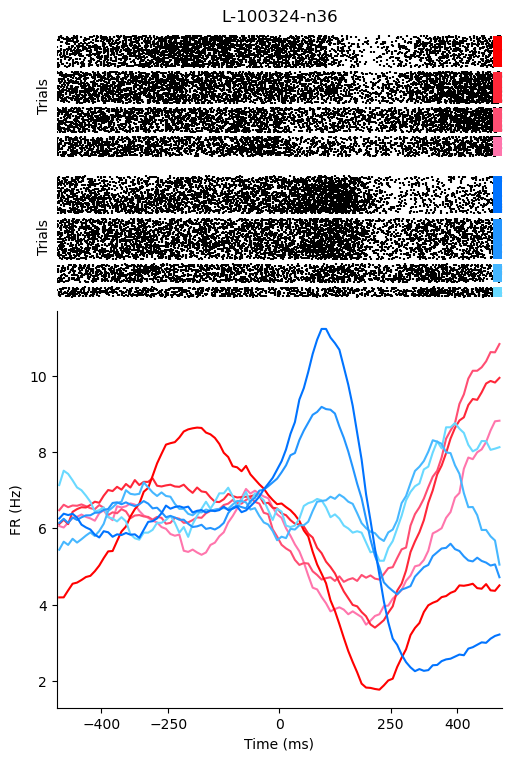

loading trial data:
loading trials:


100%|██████████| 996/996 [00:00<00:00, 1179.12it/s]


loading choice data:


100%|██████████| 996/996 [00:00<00:00, 1229.23it/s]


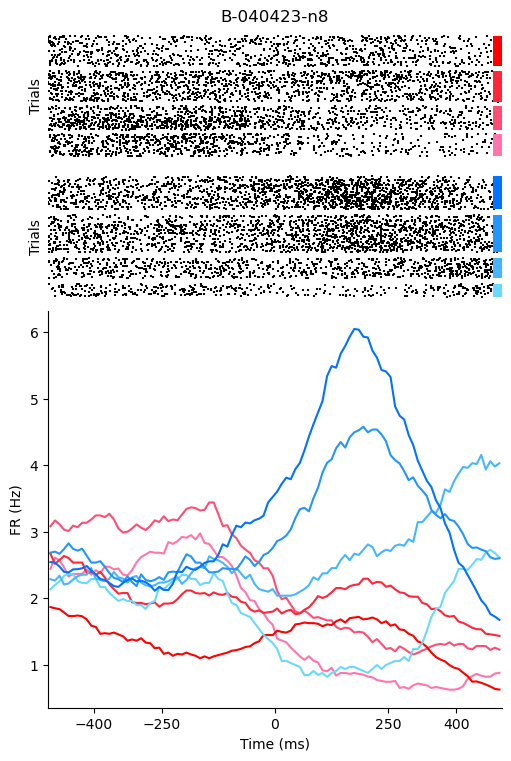

loading trial data:
loading trials:


100%|██████████| 943/943 [00:01<00:00, 655.57it/s]


loading choice data:


100%|██████████| 943/943 [00:01<00:00, 776.13it/s] 


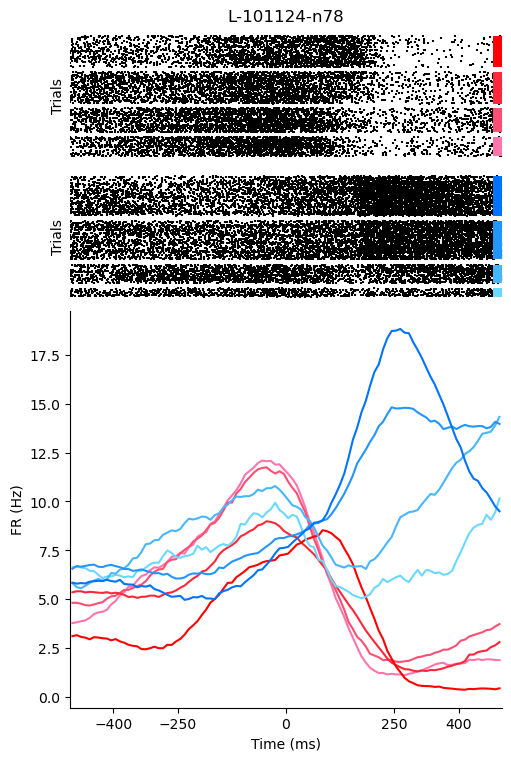

In [4]:
#f = np.hstack([fnames["bart"], fnames["london"]])
def fig4a():
    def find_filename(date, f):
        for fname in f:
            if date in fname:
                return fname

    unit1 = ["100324", 36, "london"]
    unit2 = ["040423", 8, "bart"]
    unit3 = ["101124", 78, "london"]

    for unit in [unit1, unit2, unit3]:
        fname = find_filename(unit[0], fnames[unit[2]])
        data = nwbWrapper(fname, region="OFC")
        fig, ax = plt.subplots(3, 1, figsize=(5, 7.5), gridspec_kw={"height_ratios": [1, 1, 3]}, constrained_layout=True)
        choice_and_plan_value_psth(ax, data, unit=unit[1])

        sns.despine(ax=ax[2])
        sns.despine(ax=ax[0], left=True, bottom=True)
        sns.despine(ax=ax[1], left=True, bottom=True)
        for j in range(2):
            ax[j].set_xticks([])
            ax[j].set_yticks([])
        #ax[1].set_yticks([2, 7])
        ax[2].set_xticks([-400, -250, 0, 250, 400])
        ax[0].set_title("%s-%s-n%i" % (unit[2][0].upper(), unit[0], unit[1]))
        plt.show()

fig4a()

loading trial data:
loading trials:


100%|██████████| 943/943 [00:01<00:00, 658.66it/s]


loading choice data:


100%|██████████| 943/943 [00:01<00:00, 728.97it/s] 


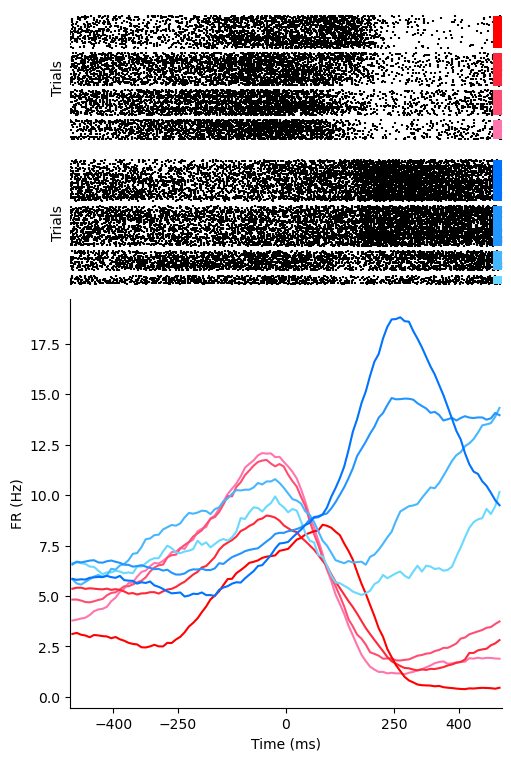

In [5]:
data = nwbWrapper(fnames["london"][-1], region="OFC")
fig, ax = plt.subplots(3, 1, figsize=(5, 7.5), gridspec_kw={"height_ratios": [1, 1, 3]}, constrained_layout=True)
choice_and_plan_value_psth(ax, data, unit=78)

sns.despine(ax=ax[2])
sns.despine(ax=ax[0], left=True, bottom=True)
sns.despine(ax=ax[1], left=True, bottom=True)
for j in range(2):
    ax[j].set_xticks([])
    ax[j].set_yticks([])
#ax[1].set_yticks([2, 7])
ax[2].set_xticks([-400, -250, 0, 250, 400])

In [6]:
def condition_averaged_spikes(X, y):
    conditions = np.unique(y)
    n_conditions = len(conditions)
    _, n_timesteps, n_neurons = X.shape
    condition_average = np.zeros((n_conditions, n_timesteps, n_neurons))
    for i, cond in enumerate(conditions):
        idx = np.where(y == cond)[0]
        condition_average[i, ...] = np.mean(X[idx, ...], axis=0)
    return condition_average, conditions

def get_spikes(fname):
    data = nwbWrapper(fname, region="OFC", to_load="all")      
    y_choice = utils.distance_to_value(data.choice_df.graph_distance.values)
    X_choice = data.choice_spikes

    plans = data.get_plan_spikes(type="psth", min_duration=100, active_prob_threshold=0.2)
    y_plan = utils.distance_to_value(plans["df"].graph_distance.values)
    X_plan = plans["spikes"]
    
    choice_avg, choice_cond = condition_averaged_spikes(X_choice, y_choice)
    plan_avg, plan_cond = condition_averaged_spikes(X_plan, y_plan)
    return dict(choice_avg=choice_avg, choice_cond=choice_cond, 
                plan_avg=plan_avg, plan_cond=plan_cond)
    
condition_averages = utils.iterate_subjects(fnames, get_spikes)

Processing bart:   0%|          | 0/8 [00:00<?, ?it/s]

loading trial data:
loading trials:


100%|██████████| 563/563 [00:00<00:00, 708.02it/s]


loading choice data:


Processing bart:  12%|█▎        | 1/8 [00:05<00:41,  5.91s/it]

...

Processing london:  86%|████████▌ | 6/7 [00:52<00:08,  8.58s/it]

loading trial data:
loading trials:


100%|██████████| 943/943 [00:01<00:00, 674.63it/s]


loading choice data:


Processing london: 100%|██████████| 7/7 [01:02<00:00,  9.00s/it]


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as sklearnPCA

def scaledPCA(n_components=20):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('pca', sklearnPCA(n_components=n_components))
    ])
    
def fit_PCA(cond_avg, n_components, bin_size, step_size):
    model = scaledPCA(n_components=n_components)
    n_cond, n_timesteps, n_neurons = cond_avg.shape
    n_bins = int(n_timesteps / step_size)
    X = np.zeros([n_cond, n_bins, n_neurons])
    for i in range(n_bins):
        start = i * step_size
        end = np.minimum(start + bin_size, n_timesteps)
        X[:, i, :] = np.mean(cond_avg[:, start:end, :].astype(float), axis=1)
    X = X.reshape(n_cond * n_bins, n_neurons)
    PCs = model.fit_transform(X)
    PCs = PCs.reshape(n_cond, n_bins, n_components)
    return model, PCs, X, (n_cond, n_bins, n_components)

def projected_response(X, model):
    scaled_X = model["scaler"].transform(X)
    projected_X = model["pca"].transform(scaled_X)
    var_explained = np.diag(np.cov(projected_X.T)) / np.diag(np.cov(scaled_X.T)).sum()    
    return dict(projection=projected_X, var_explained=var_explained)


In [8]:
class PCA:
    def __init__(self, n_components=20, bin_size=150, step_size=10):
        self.n_components = n_components
        self.bin_size = bin_size
        self.step_size = step_size
        self.model = self.scaledPCA()

    def scaledPCA(self):
        return Pipeline([
            ('scaler', StandardScaler()),
            ('pca', sklearnPCA(n_components=self.n_components))
        ])

    
    def reshape_(self, X):
        return X.reshape(self.n_cond, self.n_bins, -1)

    def fit(self, cond_avg):
        self.n_cond, self.n_timesteps, self.n_neurons = cond_avg.shape
        self.n_bins = int(self.n_timesteps / self.step_size)
        X = np.zeros([self.n_cond, self.n_bins, self.n_neurons])
        for i in range(self.n_bins):
            start = i * self.step_size
            end = np.minimum(start + self.bin_size, self.n_timesteps)
            X[:, i, :] = np.mean(cond_avg[:, start:end, :].astype(float), axis=1)
        self.X = X.reshape(self.n_cond * self.n_bins, self.n_neurons)
        PCs = self.model.fit_transform(self.X)
        self.PCs = self.reshape_(PCs)
        #return self.PCs, self.X

    def projected_response(self, X):
        scaled_X = self.model["scaler"].transform(X)
        projected_X = self.model["pca"].transform(scaled_X)
        var_explained = np.diag(np.cov(projected_X.T)) / np.diag(np.cov(scaled_X.T)).sum()    
        return dict(projection=projected_X, var_explained=var_explained)

In [136]:
# Fit PC models for individual conditiosn
PC_models = {}
for sbj in condition_averages:
    PC_models[sbj] = {}
    X_full = []
    for cond in ["choice", "plan"]:
        key = cond + "_avg"
        X = np.concat([a[key] for a in condition_averages[sbj]], axis=2)
        X_full.append(X)
        model = PCA(n_components=10, bin_size=150, step_size=10)
        model.fit(X)
        #model.fit(X - X.mean(axis=0, keepdims=True))
        PC_models[sbj][cond] = model
    
    X_full = np.concat(X_full, axis=0)
    #X_full = X_full - X_full.mean(axis=0, keepdims=True)
    model = PCA(n_components=10, bin_size=150, step_size=10)
    model.fit(X_full)
    PC_models[sbj]["full"] = model
    
# compute cross subspace alignment    
for sbj in PC_models:
    choice, plan = PC_models[sbj]["choice"], PC_models[sbj]["plan"]
    def cross_model_alignment(model1, model2):
        Q = model1.model["pca"].components_
        C = model2.model["pca"].get_covariance()
        lam = model2.model["pca"].singular_values_
        alignment = np.diag(Q @ C @ Q.T).sum()/lam.sum()
        return alignment
    PC_models[sbj]["plan_to_choice_alignment"] = cross_model_alignment(choice, plan)
    PC_models[sbj]["choice_to_plan_alignment"] = cross_model_alignment(plan, choice)
    

# compute null alignment indices    
def random_basis(C, Q, S, n_components):
    v = np.random.normal(0, 1, size=(C.shape[0], n_components))
    M = np.dot(Q * np.sqrt(S), v)
    M = M / np.linalg.norm(M, 2, axis=0)
    M, _ = np.linalg.qr(M)
    return M

from tqdm import trange
for sbj in PC_models:
    choice_avg = np.concat([a["choice_avg"] for a in condition_averages[sbj]], axis=2)
    plan_avg = np.concat([a["plan_avg"] for a in condition_averages[sbj]], axis=2)
    full_avg = np.concat([choice_avg, plan_avg], axis=0)
    n_components = 10
    model = PCA(n_components=n_components, bin_size=150, step_size=10)
    model.fit(full_avg)
    
    n_iterations = 10000
    null_alignment = np.zeros((n_iterations, ))
    C = model.model["pca"].get_covariance()
    S, Q = np.linalg.eigh(C)

    for i in trange(n_iterations):
        M_1 = random_basis(C, Q, S, n_components=n_components)
        M_2 = random_basis(C, Q, S, n_components=n_components)
        null_alignment[i] = np.diag((M_2.T @ M_1) @ (M_1.T @ M_2)).sum()/n_components
    
    PC_models[sbj]["null_alignment"] = null_alignment

100%|██████████| 10000/10000 [00:12<00:00, 775.91it/s]


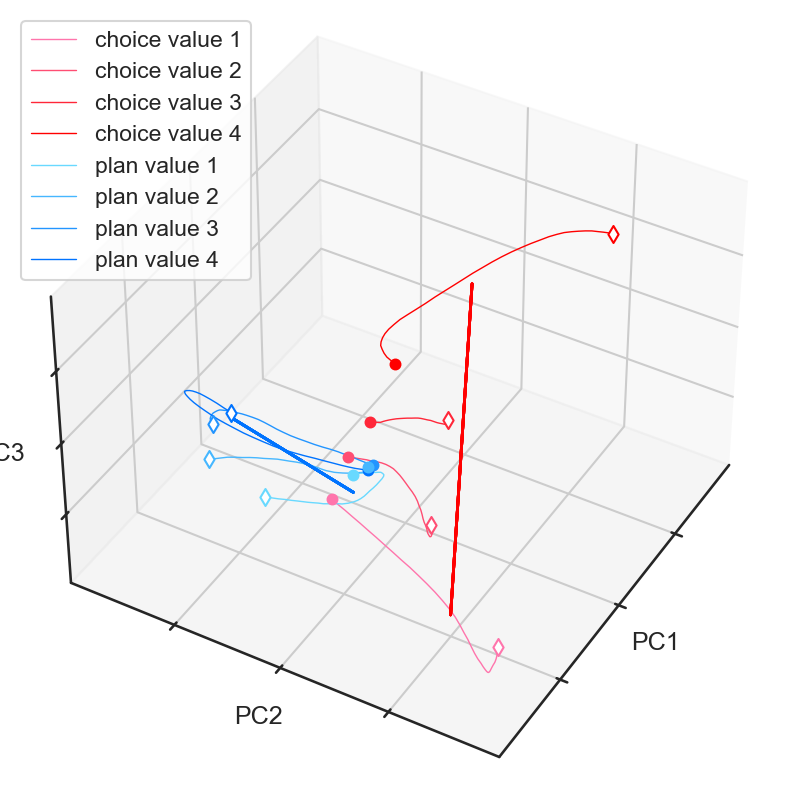

In [115]:
def fig4b(PC_models):
    sbj = "london"
    conditions = {}
    for i in range(4):
        conditions[i]  = "choice value " + str(i + 1)
        conditions[i + 4] = "plan value " + str(i + 1)
    model = PC_models[sbj]["full"]
    sns.set(style="ticks", context="talk", palette="tab10")

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    PCs = model.PCs.copy()

    l_start, l_end = 45, 85
    t_start = 50
    t_end = 80
    
    colors_all = np.vstack([choice_colors, plan_colors])

    for i in range(8):
        trace = utils.movmean(PCs[i, l_start:l_end, :].T, w=2).T
        c = colors_all[i]
        ax.plot(trace[:, 0], trace[:, 1], trace[:, 2], color=c, alpha=1, linestyle="-", lw=1, label=conditions[i])
        ax.scatter(trace[0, 0], trace[0, 1], trace[0, 2], color=c, s=50, alpha=1)
        ax.scatter(trace[-1, 0], trace[-1, 1], trace[-1, 2], s=75, alpha=1, marker="d", facecolor="white", edgecolor=c)

        mean_pcs_exe = PCs[:4, t_start:t_end, :].mean(axis=1)
        mean_pcs_plan = PCs[4:, t_start:t_end, :].mean(axis=1)    

        def plot_linear_regression(ax, mean_pcs, colors):
            model = LinearRegression().fit(mean_pcs[:, [0, 1]], mean_pcs[:, 2])
            exe_coef = model.coef_.copy()
            exe_intercept = model.intercept_

            X, Y = np.linspace(mean_pcs[0, 0], mean_pcs[3, 0]), np.linspace(mean_pcs[0, 1], mean_pcs[3, 1])
            Z = exe_coef[0] * X + exe_coef[1] * Y + exe_intercept
            ax.plot(X, Y, Z, color=colors[-1], lw=2)
            return

        plot_linear_regression(ax, mean_pcs_exe, choice_colors)
        plot_linear_regression(ax, mean_pcs_plan, plan_colors)

        ax.set_xlim([-20, 40])
        ax.set_ylim([-30, 30])
        ax.set_zlim([-30, 40])

        ax.set_xlabel("PC%i" % 1)
        ax.set_ylabel("PC%i" % 2)
        ax.set_zlabel("PC%i" % 3)

    ax.set_xticks([-5, 10, 25], labels=["", "", ""])
    ax.set_yticks([-30 + 15 , -30 + 30, -30 + 45], labels=["", "", ""])
    ax.set_zticks([-30 + 70/4, -30 + 140/4, -30 + 210/4], labels=["", "", ""])    
    ax.legend()
    ax.view_init(40, 210) 
    
    return fig, ax

fig, ax = fig4b(PC_models)
plt.show()

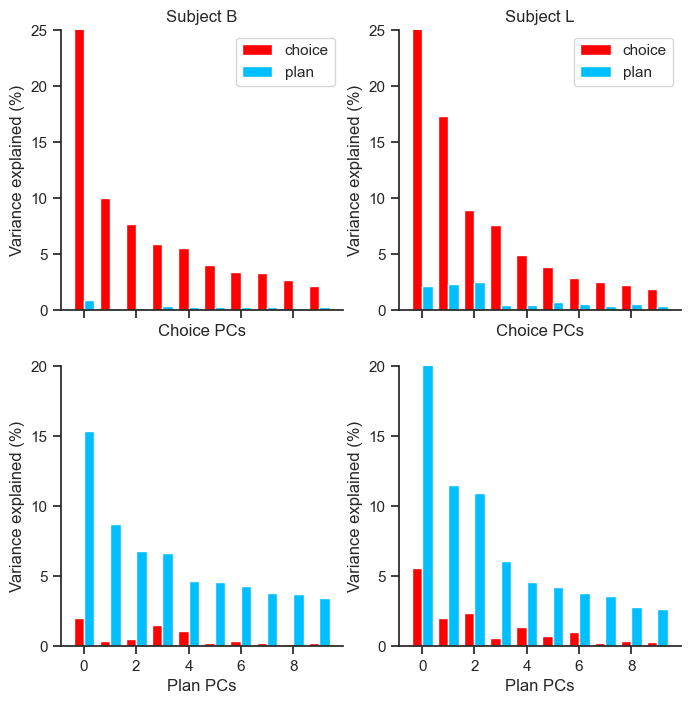

In [90]:
def fig4C(PC_models):
    sns.set(style="ticks")
    fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharey=False, sharex=True)
    sns.despine()

    for i, sbj in enumerate(PC_models):
        choice = PC_models[sbj]["choice"]
        plan = PC_models[sbj]["plan"]
        choice_to_choice = choice.projected_response(choice.X)
        plan_to_choice = choice.projected_response(plan.X)
        
        plan_to_plan = plan.projected_response(plan.X)
        choice_to_plan = plan.projected_response(choice.X)
        
        n_components = 10
        w = 0.4
        x_choice = np.arange(0, n_components) - w/2
        x_plan = np.arange(0, n_components) + w/2
        ax = axes[:, i]
        c_choice = "red"
        c_plan = "deepskyblue"
        
        # Projection into choice subspace
        ax[0].bar(x_choice, choice_to_choice["var_explained"]*100, width=w, label="choice", color=c_choice)
        ax[0].bar(x_plan, plan_to_choice["var_explained"]*100, width=w, label="plan", color=c_plan)
        ax[0].set_ylim([0, 25])
        ax[0].legend()
        ax[0].set_xlabel("Choice PCs")
        ax[0].set_title("Subject %s" % sbj[0].capitalize())
        
        # Projection into plan subspace
        ax[1].bar(x_choice, choice_to_plan["var_explained"]*100, width=w, label="choice", color=c_choice)
        ax[1].bar(x_plan, plan_to_plan["var_explained"]*100, width=w, label="plan", color=c_plan)
        ax[1].set_ylim([0, 20])
        ax[1].set_yticks([0, 5, 10, 15, 20])
        ax[1].set_xlabel("Plan PCs")
        ax[0].set_ylabel("Variance explained (%)")
        ax[1].set_ylabel("Variance explained (%)")
    return fig, ax 

fig4C(PC_models)
plt.show()

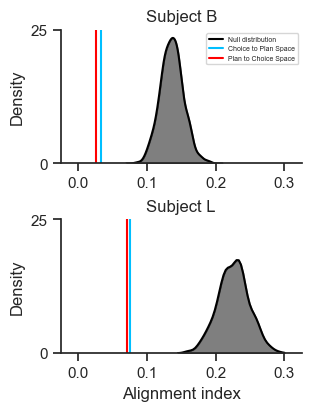

In [116]:
def fig4d(PC_models):
    sns.set(style="ticks")
    fig, ax = plt.subplots(2, 1, figsize=(3, 4), constrained_layout=True)

    from scipy.stats import gaussian_kde, ttest_ind
            
    for i, sbj in enumerate(PC_models):
        PC_models[sbj]["null_alignment"]
        kde = gaussian_kde(PC_models[sbj]["null_alignment"])
        if i == 0:
            x_values = np.linspace(0.07, 0.21, 1000)  # Define the range for x values
        else:
            x_values = np.linspace(0.145, 0.3)
        kde_values = kde(x_values)  # Get the density values
        ax[i].fill_between(x_values, 0, kde_values, color="black", alpha=0.5)
        ax[i].plot(x_values, kde_values, color="black", label="Null distribution")
        
        ax[i].axvline(PC_models[sbj]["choice_to_plan_alignment"], color="deepskyblue", linestyle="-", label="Choice to Plan Space")
        ax[i].axvline(PC_models[sbj]["plan_to_choice_alignment"], color="red", linestyle="-", label="Plan to Choice Space")
        
        ax[i].set_xlim([-0.025, 0.325])
        ax[i].set_ylim([0, 25])
        ax[i].set_yticks([0, 25])
        ax[i].set_xticks([0, 0.1, 0.2, 0.3])

        if i == 0:
            ax[i].legend(fontsize=5)
        ax[i].set_ylabel("Density")
        ax[i].set_title("Subject " + sbj[0].capitalize())
        
        if i == 1:
            ax[i].set_xlabel("Alignment index")
        sns.despine()
    return fig, ax 

fig4d(PC_models)
plt.show()

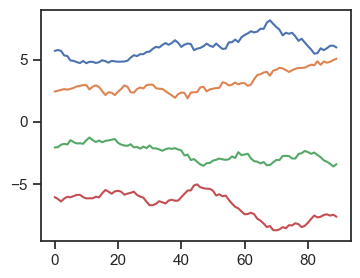

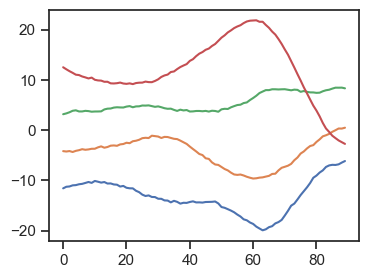

In [134]:
for i, sbj in enumerate(PC_models):
    choice = PC_models[sbj]["choice"]
    plan = PC_models[sbj]["plan"]
    choice_to_choice = choice.projected_response(choice.X)
    plan_to_choice = choice.projected_response(plan.X)
    plan_to_plan = plan.projected_response(plan.X)
    choice_to_plan = plan.projected_response(choice.X)
    fig, ax = plt.subplots(1, 1, figsize=(4, 3))
    plt.plot(choice_to_plan["projection"].reshape(-1, 100, 10)[:, :90, 0].T)

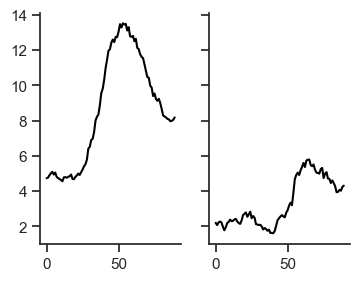

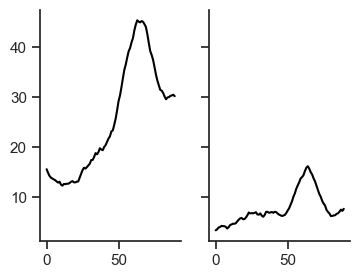

<Figure size 640x480 with 0 Axes>

In [135]:
for i, sbj in enumerate(PC_models):
    choice = PC_models[sbj]["choice"]
    plan = PC_models[sbj]["plan"]
    choice_to_choice = choice.projected_response(choice.X)
    plan_to_choice = choice.projected_response(plan.X)
    plan_to_plan = plan.projected_response(plan.X)
    choice_to_plan = plan.projected_response(choice.X)
    fig, ax = plt.subplots(1, 2, figsize=(4, 3), sharey=True)
    #for i in range(10):
        #ax[0].plot(choice_to_plan["projection"].reshape(-1, 100, 10)[:, :100, i].var(axis=0), c="grey", alpha=0.5)
        #ax[1].plot(plan_to_choice["projection"].reshape(-1, 100, 10)[:, :100, i].var(axis=0), c="grey", alpha=0.5)
    ax[0].plot(np.var(choice_to_plan["projection"].reshape(-1, 100, 10)[:, :90, :], axis=0).mean(axis=1), c="black", alpha=1)
    #ax[0].plot(np.var(choice_to_choice["projection"].reshape(-1, 100, 10)[:, :90, :], axis=0).mean(axis=1), c="red", alpha=1)
    ax[1].plot(np.var(plan_to_choice["projection"].reshape(-1, 100, 10)[:, :90, :], axis=0).mean(axis=1), c="black", alpha=1)
    sns.despine()
    plt.show()

sns.despine()

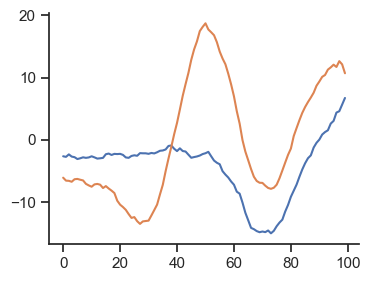

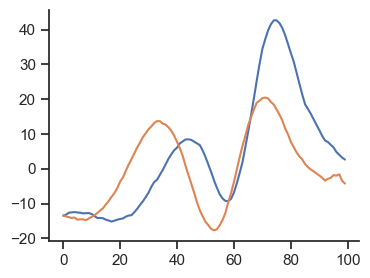

In [56]:
# subspace occupancy
for i, sbj in enumerate(PC_models):
    choice = PC_models[sbj]["choice"]
    plan = PC_models[sbj]["plan"]
    choice_to_choice = choice.projected_response(choice.X)
    plan_to_choice = choice.projected_response(plan.X)
    plan_to_plan = plan.projected_response(plan.X)
    choice_to_plan = plan.projected_response(choice.X)
    fig, ax = plt.subplots(1, 1, figsize=(4, 3))
    #plt.plot(np.var(plan_to_plan["projection"].reshape(-1, 100, 10), axis=0).sum(axis=1))
    plt.plot(np.mean(choice_to_plan["projection"].reshape(-1, 100, 10), axis=0).sum(axis=1))
    
    plt.plot(np.mean(choice_to_choice["projection"].reshape(-1, 100, 10), axis=0).sum(axis=1))
    #plt.plot(np.var(plan_to_choice["projection"].reshape(-1, 100, 10), axis=0).sum(axis=1))
    sns.despine()

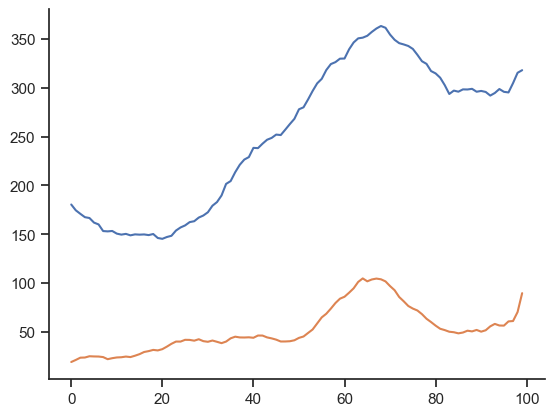

In [50]:
plt.plot(np.var(choice_to_plan["projection"].reshape(-1, 100, 10), axis=0).sum(axis=1))
plt.plot(np.var(plan_to_choice["projection"].reshape(-1, 100, 10), axis=0).sum(axis=1))
sns.despine()

In [40]:
test = np.tile(np.array([1, 2, 3]), 4)
test, test.reshape(-1, 3)

(array([1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3]),
 array([[1, 2, 3],
        [1, 2, 3],
        [1, 2, 3],
        [1, 2, 3]]))